Task 3: Symmetric vs. Asymmetric INT8 Quantization

Objective

Implement and compare symmetric and asymmetric INT8 quantization. Understand why weights (centered around zero) and activations (often non-negative) benefit from different methods.

In [60]:
import numpy as np

In [61]:
def calc_scale_zero_point(tensor:np.ndarray, q_min:int = -127, q_max:int = 127, affine:bool = False):
    t_min, t_max = tensor.min(), tensor.max()
    
    # affine quantization logic
    if affine:
        t_range = t_max - t_min
        if t_range < 1e-11:
            return 1.0, 0
        scale = t_range / (q_max - q_min)
        
        # clamp zero_point to valid integer bounds (used regular functions instead of tensor bound functions)
        zero_point = q_min - round(t_min / scale)
        zero_point = max(q_min, min(q_max, zero_point))
        return scale, zero_point

    # asymmetric quantization
    max_val = max(abs(t_min), abs(t_max))
    if max_val < 1e-11:
        return 1.0, 0  

    q_abs_max = max(abs(q_min), abs(q_max)) 
    scale = max_val / q_abs_max
    zero_point = 0
    return scale, zero_point

In [62]:
# Part A: Symmetric INT8 Quantization
def symmetric_quantize(tensor:np.ndarray):
    scale, _ = calc_scale_zero_point(tensor)
    return np.clip(np.round(tensor / scale), a_min=-127, a_max=127).astype(np.int8), scale, 0

# Part B: Asymmetric INT8 Quantization
def asymmetric_quantize(tensor:np.ndarray):
    scale, zero_point = calc_scale_zero_point(tensor, q_min=-128, q_max=127, affine=True)
    return np.clip(np.round(tensor / scale + zero_point), a_min=-128, a_max=127).astype(np.int8), scale, zero_point

# Part C: Dequantization
def dequantize(quantized_tensor:np.ndarray, scale:float, zero_point:int):
    return scale * (quantized_tensor.astype(np.float32) - zero_point)

In [63]:
def calculate_metrics(tensor, quantized_tensor, scale, zero_point, affine):
    # dequantize
    dequantized = dequantize(quantized_tensor, scale, zero_point)
    # error
    error = tensor - dequantized
    abs_error = np.abs(error)
    mae = np.mean(abs_error)
    mse = np.mean(error ** 2)
    max_error = np.max(abs_error)
    
    # quantization range
    if affine:
        q_min, q_max = -128, 127
    else:
        q_min, q_max = -127, 127

    sat_min = np.sum(quantized_tensor == q_min)
    sat_max = np.sum(quantized_tensor == q_max)
    sat_total = sat_min + sat_max
    
    return mae, mse, max_error, sat_min, sat_max, sat_total

In [64]:
weights = np.array([
[-1.8, -0.9, 0.0, 0.7, 1.5],
[-2.4, -0.3, 0.2, 1.1, 2.0]
], dtype=np.float32)

activations = np.array([
[0.0, 0.3, 0.8, 1.4, 2.1],
[0.1, 0.6, 1.0, 1.8, 3.2]
], dtype=np.float32)

In [65]:
import pandas as pd

rows = [("Weights", "Symmetric", weights, *symmetric_quantize(weights)),
    ("Weights", "Asymmetric", weights, *asymmetric_quantize(weights)),
    ("Activations", "Symmetric", activations, *symmetric_quantize(activations)),
    ("Activations", "Asymmetric", activations, *asymmetric_quantize(activations))]

table = []

for tensor_name, method, tensor, q_tensor, scale, zero_point in rows:
    mae, mse, max_err, sat_min, sat_max, sat_total = calculate_metrics(tensor, q_tensor, scale, zero_point, method == "Asymmetric")
    table.append([tensor_name, method, scale, zero_point, mae, mse, max_err, sat_min, sat_max, sat_total])

df = pd.DataFrame(table,
    columns=["Tensor", "Method", "Scale", "Zero Pt", "MAE", "MSE", "Max Err", "Sat(min)", "Sat(max)", "Sat(total)"])

print(df.to_string(index=False))

     Tensor     Method    Scale  Zero Pt      MAE      MSE  Max Err  Sat(min)  Sat(max)  Sat(total)
    Weights  Symmetric 0.018898        0 0.003701 0.000022 0.007874         1         0           1
    Weights Asymmetric 0.017255       11 0.003804 0.000021 0.007451         1         1           2
Activations  Symmetric 0.025197        0 0.005276 0.000045 0.011024         0         1           1
Activations Asymmetric 0.012549     -128 0.002627 0.000011 0.005490         1         1           2


## Part D: Apply Both Methods and Compare

Apply both methods to weights and activations separately. 

Fill in this table: 
| Tensor | Method | Scale | Zero Pt | MAE | MSE | Max Err | Sat(min) | Sat(max) | Sat(total) |
|----|-----|----------|---------|----------|----------|----------|----------|----------|-----|
| Weights | Symmetric | 0.018898 | 0 | 0.003701 | 0.000022 | 0.007874 | 1 | 0 | 1 |
| Weights | Asymmetric | 0.017255 | 11 | 0.003804 | 0.000021 | 0.007451 | 1 | 1 | 2 |
| Activations | Symmetric | 0.025197 | 0 | 0.005276 | 0.000045 | 0.011024 | 0 | 1 | 1 |
| Activations | Asymmetric | 0.012549 | -128 | 0.002627 | 0.000011 | 0.005490 | 1 | 1 | 2 |

## Part E: Compare Reconstructed Values

For both tensors, display side by side: Original tensor, symmetrically quantized (INT8), Symmetrically dequantized (float), Asymmetrically quantized (INT8), Asymmetrically dequantized (float).

In [66]:
w_a = {"Weight": weights, "Activation": activations}

for key in w_a.keys():
    
    # find symmetric quantization
    sym_q, sym_s, sym_z = symmetric_quantize(w_a[key])
    sym_dq = dequantize(sym_q, sym_s, sym_z)
    
    # find affine quantization
    asym_q, asym_s, asym_z = asymmetric_quantize(w_a[key])
    asym_dq = dequantize(asym_q, asym_s, asym_z)
    df = pd.DataFrame({"Original": w_a[key].flatten(), "Sym Quant": sym_q.flatten(), "Sym Dequant": sym_dq.flatten(), 
    "Asym Quant": asym_q.flatten(), "Asym Dequant": asym_dq.flatten()})
    
    print(f"\n{key}")
    print(df.to_string(index=False))


Weight
 Original  Sym Quant  Sym Dequant  Asym Quant  Asym Dequant
     -1.8        -95    -1.795276         -93     -1.794510
     -0.9        -48    -0.907087         -41     -0.897255
      0.0          0     0.000000          11      0.000000
      0.7         37     0.699213          52      0.707451
      1.5         79     1.492913          98      1.501176
     -2.4       -127    -2.400000        -128     -2.398431
     -0.3        -16    -0.302362          -6     -0.293333
      0.2         11     0.207874          23      0.207059
      1.1         58     1.096063          75      1.104314
      2.0        106     2.003150         127      2.001569

Activation
 Original  Sym Quant  Sym Dequant  Asym Quant  Asym Dequant
      0.0          0     0.000000        -128      0.000000
      0.3         12     0.302362        -104      0.301176
      0.8         32     0.806299         -64      0.803137
      1.4         56     1.411024         -16      1.405490
      2.1         83

## Part F: Outlier Experiment

outlier_tensor = np.array(
[-0.5, -0.2, 0.0, 0.3, 0.7, 12.0], dtype=np.float32
)

1. Apply both methods to outlier_tensor. Report Scale, Zero Point, MAE, MSE, Max Error, and per-element error.

2. Remove 12.0 and repeat with the remaining 5 values.

        Version     Method    Scale  Zero Point      MAE      MSE  Max Error
   With Outlier  Symmetric 0.094488           0 0.015617 0.000441   0.038583
   With Outlier Asymmetric 0.049020        -118 0.007190 0.000072   0.013725
Without Outlier  Symmetric 0.005512           0 0.001102 0.000002   0.002362
Without Outlier Asymmetric 0.004706         -22 0.001176 0.000002   0.002353


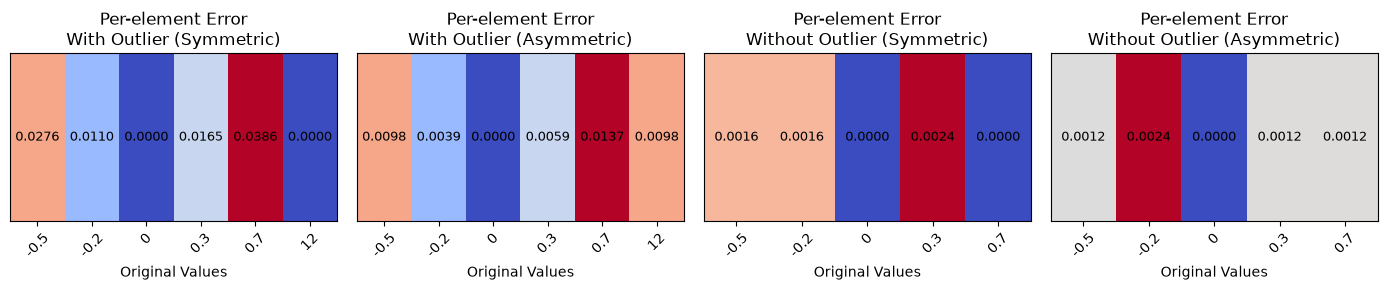

In [73]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 4, figsize=(14, 3))

outlier = np.array([-0.5, -0.2, 0.0, 0.3, 0.7, 12.0], dtype=np.float32)
without_outlier = np.array([-0.5, -0.2, 0.0, 0.3, 0.7], dtype=np.float32)

outlier_dict = {"With Outlier": outlier, "Without Outlier": without_outlier}

inputs = [("With Outlier", "Symmetric", ax[0]), ("With Outlier", "Asymmetric", ax[1]), ("Without Outlier", "Symmetric", ax[2]), ("Without Outlier", "Asymmetric", ax[3])]
quant_range = {"Symmetric": (-127, 127), "Asymmetric": (-128, 127)}

table = []

for version, quant_type, axis in inputs:
    tensor = outlier_dict[version]
    
    if quant_type == "Symmetric":
        quantized_tensor, scale, zero_point = symmetric_quantize(tensor)
    else:
        quantized_tensor, scale, zero_point = asymmetric_quantize(tensor)
    
    dequantized_tensor = dequantize(quantized_tensor, scale, zero_point)
        
    mae, mse, max_err, _, _, _ = calculate_metrics(tensor, quantized_tensor, scale, zero_point, quant_type == "Asymmetric")
    table.append((version, quant_type, scale, zero_point, mae, mse, max_err))
    error = np.abs(tensor - dequantized_tensor)

    axis.set_title(f"Per-element Error\n{version} ({quant_type})")
    axis.imshow(error.reshape(1, -1), cmap="coolwarm", aspect="auto")

    # Display error value inside each cell
    for i, value in enumerate(error):
        axis.text(i, 0,f"{value:.4f}",ha="center", va="center", color="black",fontsize=9)

    # original tensor values on x-axis
    axis.set_xticks(range(len(tensor)))
    axis.set_xticklabels([f"{x:g}" for x in tensor], rotation=45)
    axis.set_yticks([])
    axis.set_xlabel("Original Values")
df = pd.DataFrame(table, columns=["Version", "Method", "Scale", "Zero Point", "MAE", "MSE", "Max Error"])
print(df.to_string(index=False))
plt.tight_layout()
plt.show()


Part F: Outlier Experiment (Answer)
## Results with and without Outlier

| Version | Method | Scale | Zero Point | MAE | MSE | Max Error |
|----|-----|----------|-----|----------|----|----|
| With Outlier | Symmetric | 0.094488 | 0 | 0.015617 | 0.000441 | 0.038583 |
| With Outlier | Asymmetric | 0.049020 | -118 | 0.007190 | 0.000072 | 0.013725 |
| Without Outlier | Symmetric | 0.005512 | 0 | 0.001102 | 0.000002 | 0.002362 |
| Without Outlier | Asymmetric | 0.004706 | -22 | 0.001176 | 0.000002 | 0.002353 |
### Per Element Error:
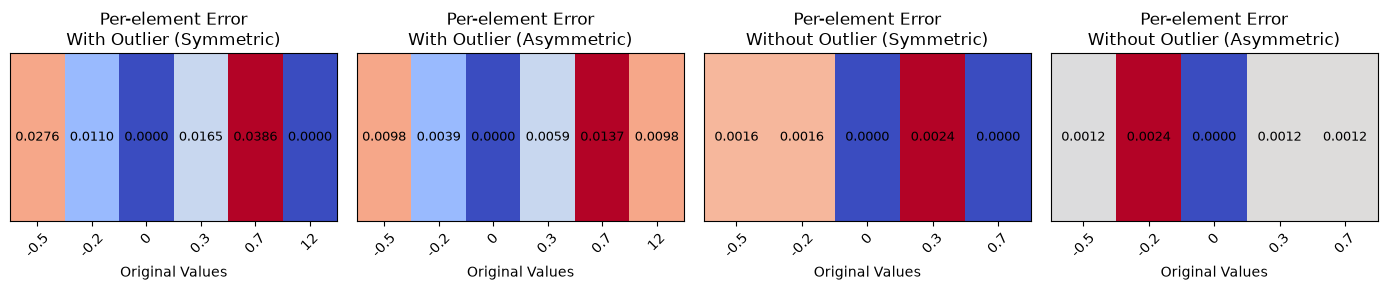
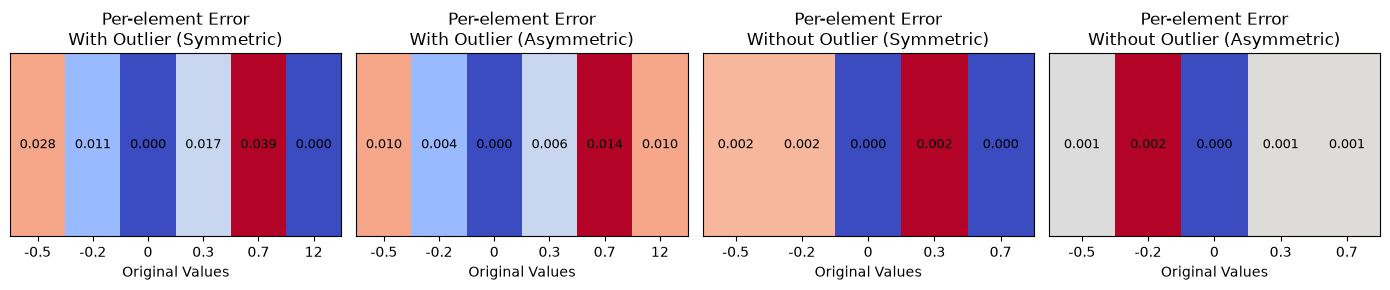

## Observation:
- **WRT Weights** For the given example both symmetric and asymmetric methods have no difference in terms of error (~0.0001 difference in MAE), but, in general symmetric quantization is preferred during training as the initial random weights chosen will are normally distributed.
- **WRT Activations** For the given activation tensor the asymmetric is clearly the winner as they are mostly positive (similar to ReLU activation function), using symmetric method will waste half positive range and also induce variation due to conversion between different signed values.
- **WRT Outliers** Outliers forces a much larger scale in both methods, increasing error for all other values. After removing the outlier, both methods recover and achieve very low error.

## Conclusions based on Observations
- Use Symmetric quantization for weights.
- Use Asymmetric quantization for activations.
- Always handle outliers carefully (using clipping or outlier-aware calibration) or else, quantization quality collapses. 